# Diabetes Prediction using ML models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Project overview

- **Dataset**: PIMA Indians Diabetes Dataset
- **Goal**: To predict diabetes with high accuracy
- **Evaluation Metrics**: Accuracy score on training and test data

## 2. Loading the Dataset

We load the *PIMA Indians Diabetes Dataset*, which contains diagnostic measurements for females of prima indians heritage aged 21 and older.

## Dataset features:

  1. **Pregnancies**: Number of times pregnant
  2. **Glucose**: Plasma glucose concerntration(2 hrs in an oral glucose tolerance test)
  3. **BloodPressures**: blood pressure(mm Hg)
  4. **SkinThickness**: Triceps skin fold thickness(mm)
  5. **Insulin**: 2-Hour serum insulin(mu U/ml)
  6. **BMI**: Body mass index(weight in kg/(height in m)^2)
  7. **DiabetesPedigreeFunction**: Diabetes Pedigree Function(genetic influence)
  8. **Age**: Age in years
  9. **Outcome**: Target variable(1=diabetic, 0=non-diabetic)

In [2]:
df = pd.read_excel('diabetes.xlsx')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0
...,...,...,...,...,...,...,...,...,...
1995,2,75,64,24,55,29.7,0.370,33,0
1996,8,179,72,42,130,32.7,0.719,36,1
1997,6,85,78,0,0,31.2,0.382,42,0
1998,0,129,110,46,130,67.1,0.319,26,1


In [3]:
df.info

<bound method DataFrame.info of       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0               2      138             62             35        0  33.6   
1               0       84             82             31      125  38.2   
2               0      145              0              0        0  44.2   
3               0      135             68             42      250  42.3   
4               1      139             62             41      480  40.7   
...           ...      ...            ...            ...      ...   ...   
1995            2       75             64             24       55  29.7   
1996            8      179             72             42      130  32.7   
1997            6       85             78              0        0  31.2   
1998            0      129            110             46      130  67.1   
1999            2       81             72             15       76  30.1   

      DiabetesPedigreeFunction  Age  Outcome  
0                   

In [4]:
df.shape

(2000, 9)

In [5]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [6]:
df.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
813,5,122,86,0,0,34.7,0.290,33,0
1461,5,136,84,41,88,35.0,0.286,35,1
1498,6,107,88,0,0,36.8,0.727,31,0
860,1,100,66,29,196,32.0,0.444,42,0
1331,1,79,60,42,48,43.5,0.678,23,0


In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.70050,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.30125,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.00000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.00000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.00000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.00000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [8]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

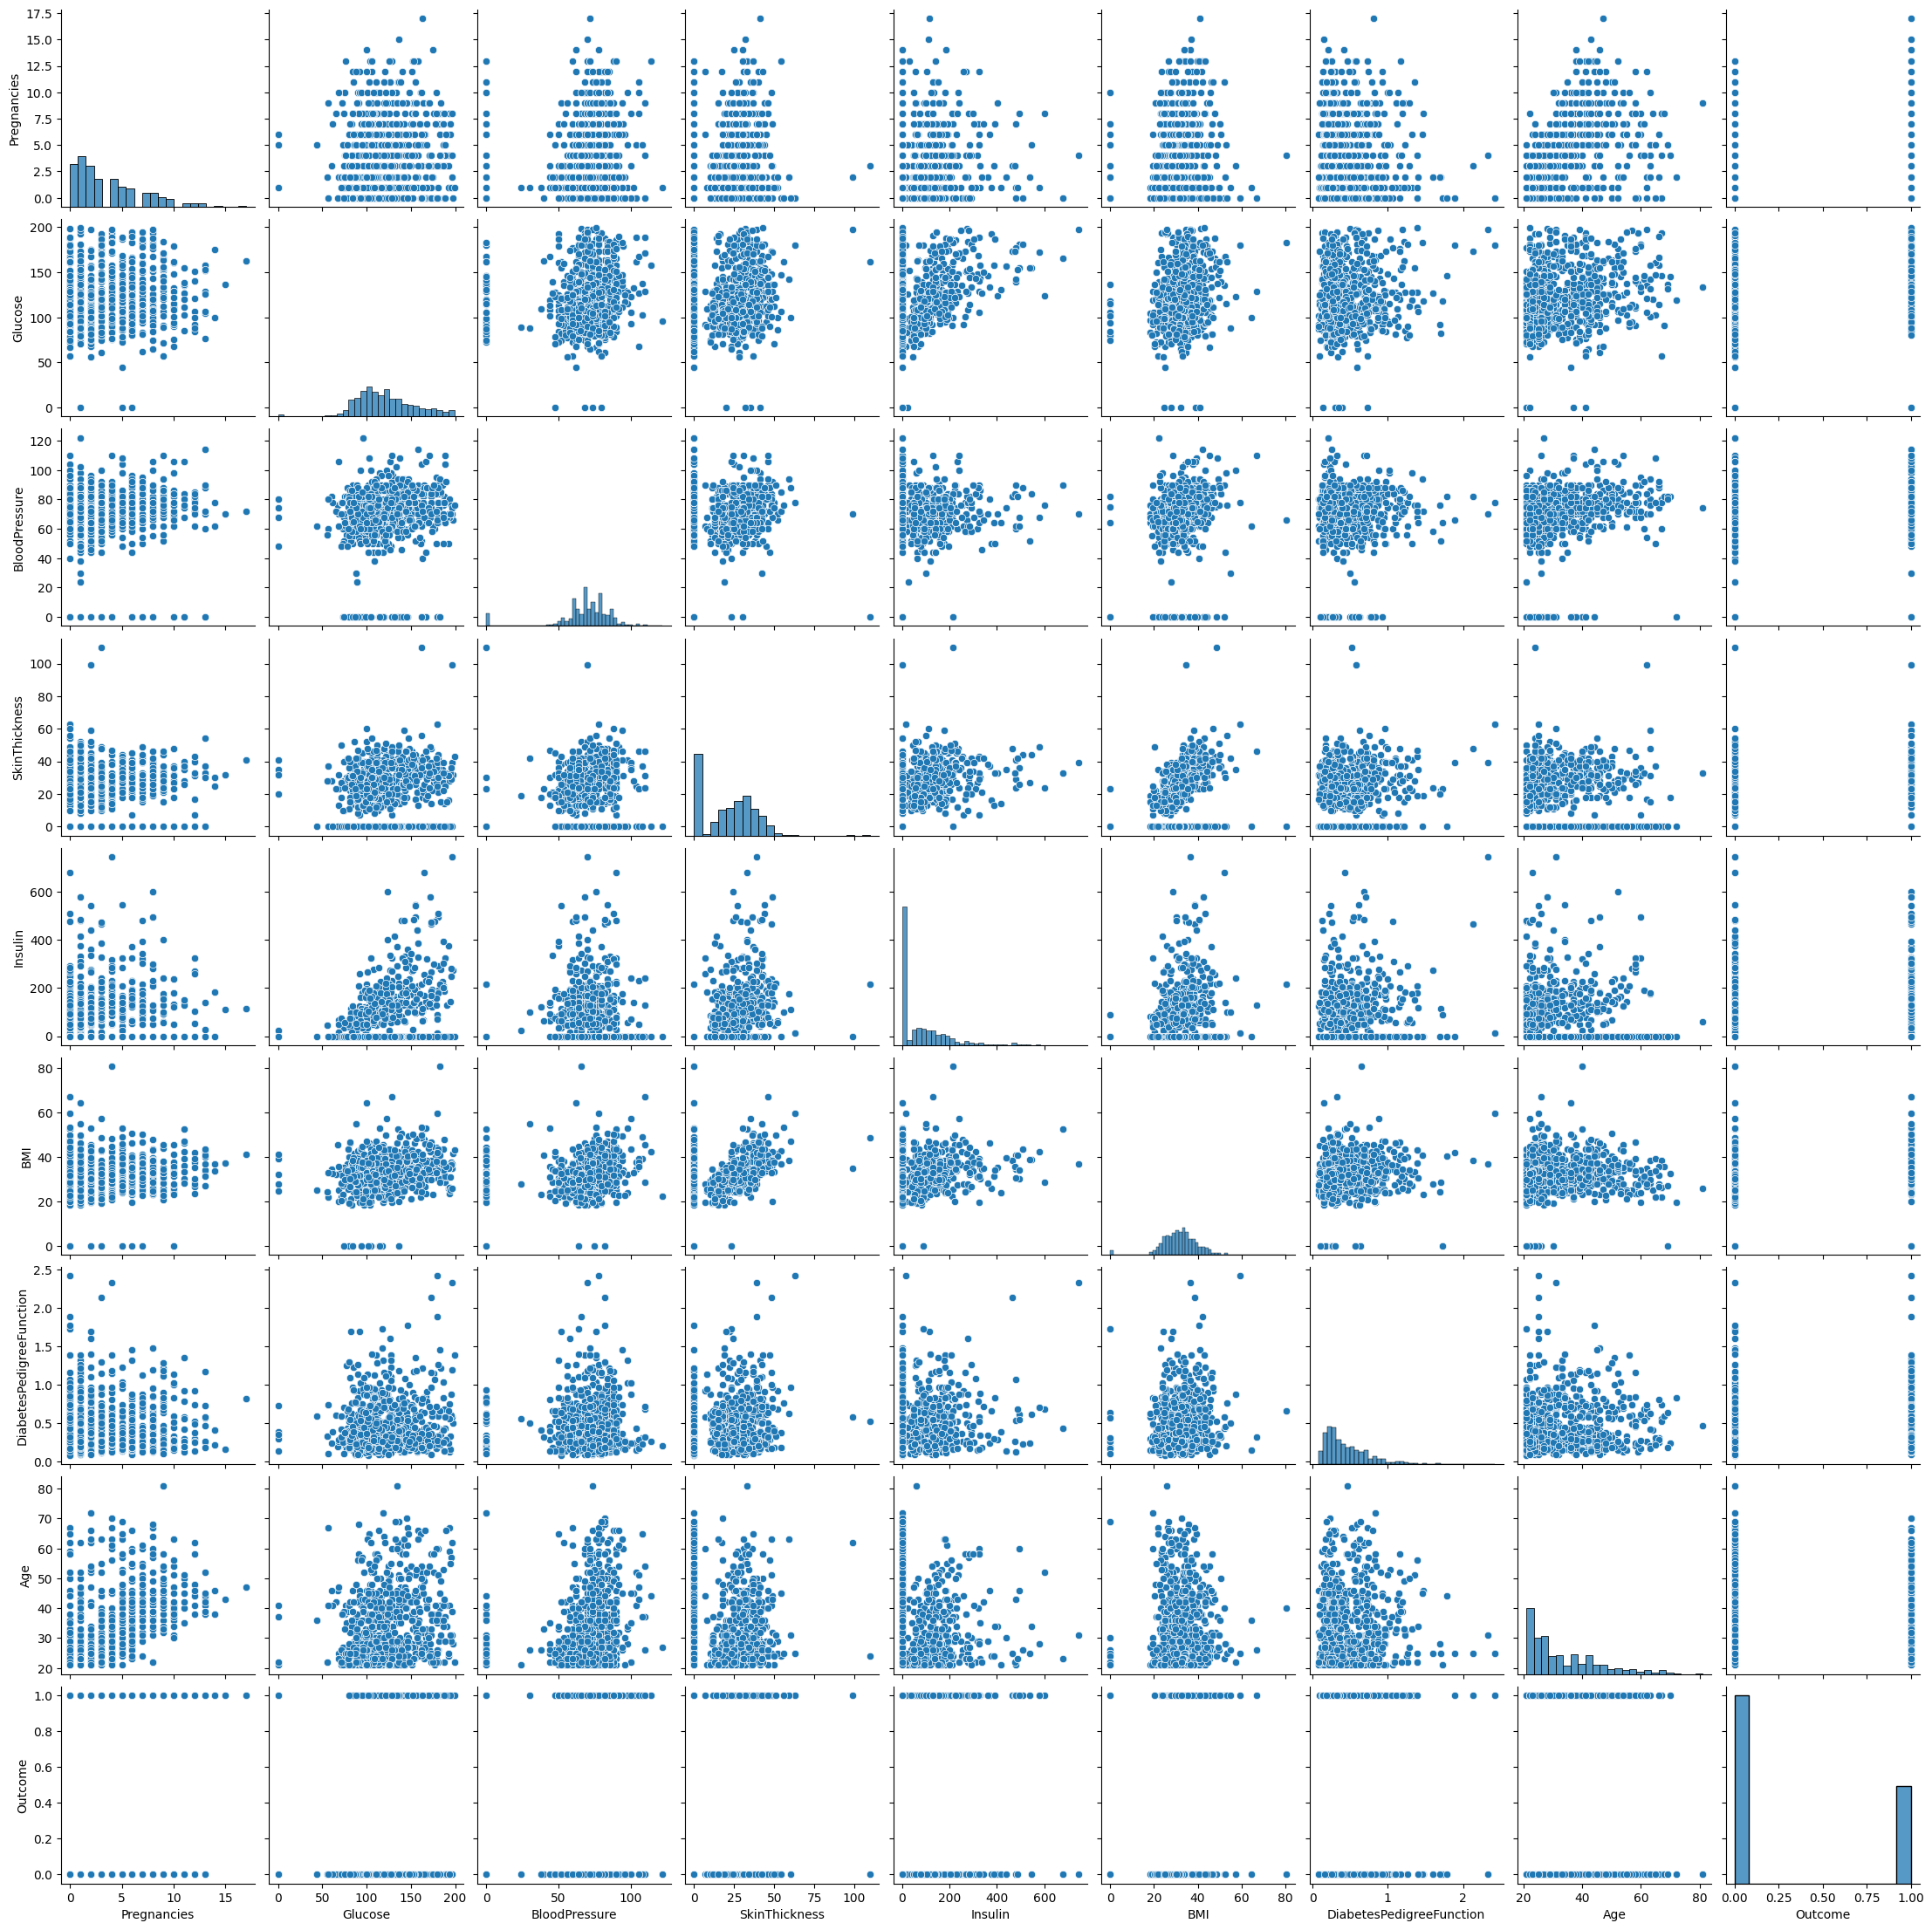

In [10]:
sns.pairplot(df)

In [11]:
num_col=df.select_dtypes(include=['int64', 'float']).columns
num_col

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [12]:
print(df.columns)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


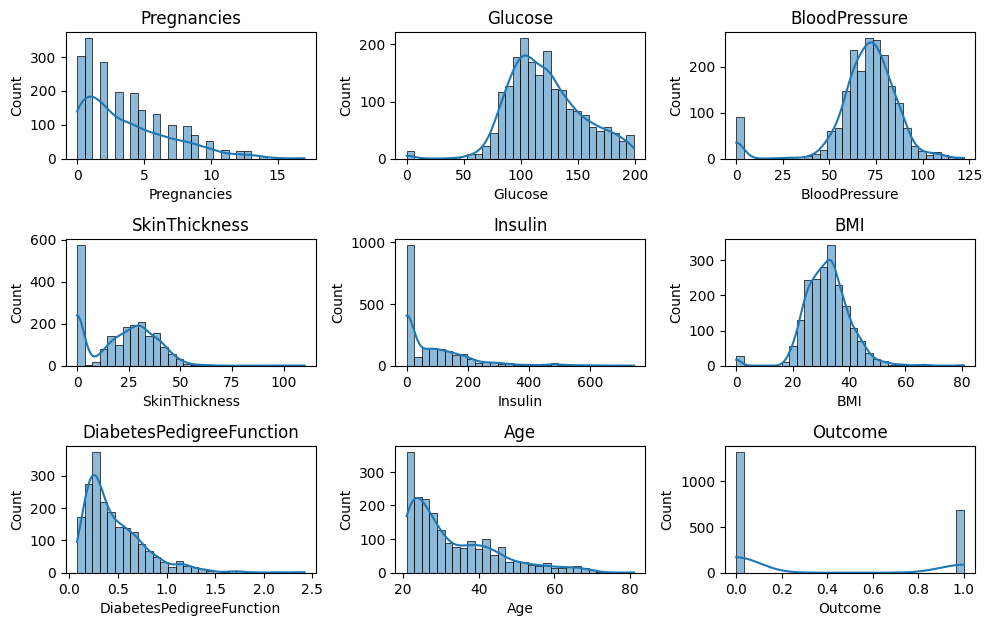

In [13]:
plt.figure(figsize=(10,8))
for i,col in enumerate(num_col):
    plt.subplot(4,3,i+1)
    sns.histplot(df[col],bins=30,kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

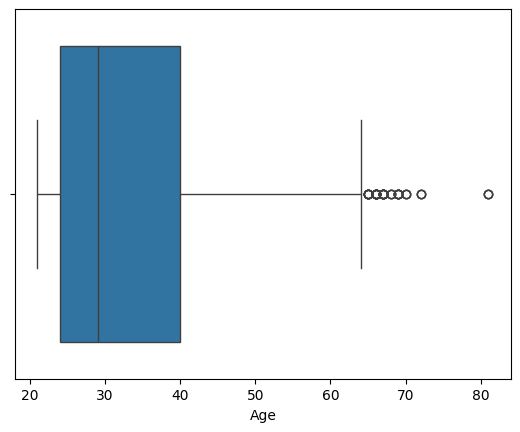

In [14]:
sns.boxplot(x=df['Age'])
plt.show()

In [15]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.120681,0.148650,-0.061419,-0.075128,0.019566,-0.024642,0.537499,0.225420
Glucose,0.120681,1.000000,0.138044,0.062368,0.320371,0.226864,0.123243,0.254496,0.458421
BloodPressure,0.148650,0.138044,1.000000,0.198800,0.087384,0.281545,0.051331,0.238375,0.075958
SkinThickness,-0.061419,0.062368,0.198800,1.000000,0.448859,0.393760,0.178299,-0.111034,0.076040
Insulin,-0.075128,0.320371,0.087384,0.448859,1.000000,0.223012,0.192719,-0.085879,0.120924
BMI,0.019566,0.226864,0.281545,0.393760,0.223012,1.000000,0.125719,0.038987,0.276726
DiabetesPedigreeFunction,-0.024642,0.123243,0.051331,0.178299,0.192719,0.125719,1.000000,0.026569,0.155459
Age,0.537499,0.254496,0.238375,-0.111034,-0.085879,0.038987,0.026569,1.000000,0.236509
Outcome,0.225420,0.458421,0.075958,0.076040,0.120924,0.276726,0.155459,0.236509,1.000000


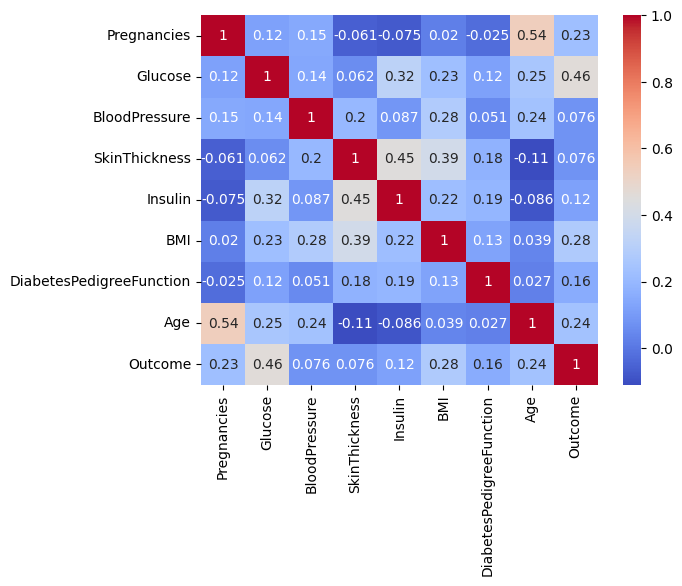

In [16]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

In [18]:
x = df.drop("Outcome", axis=1)
y = df["Outcome"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [20]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel="rbf"),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [21]:
results = []

for name, model in models.items():

    # Scale only where needed
    if name in ["Logistic Regression", "SVM", "KNN"]:
        model.fit(x_train, y_train)
        preds = model.predict(x_test)
    else:
        model.fit(x_train, y_train)
        preds = model.predict(x_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append([name, acc, prec, rec, f1])

In [22]:
 cm = confusion_matrix(y_test, preds)

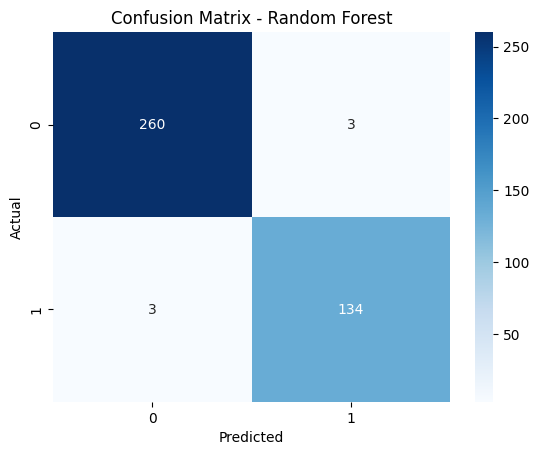

In [23]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
print(f"\n{name} Classification Report:\n")
print(classification_report(y_test, preds))


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       263
           1       0.98      0.98      0.98       137

    accuracy                           0.98       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.98      0.98       400



In [25]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
4,Decision Tree,0.9925,0.978571,1.000000,0.989170
5,Random Forest,0.9850,0.978102,0.978102,0.978102
1,SVM,0.8425,0.824561,0.686131,0.749004
2,KNN,0.8150,0.748031,0.693431,0.719697
0,Logistic Regression,0.8025,0.773585,0.598540,0.674897
3,Naive Bayes,0.7650,0.669291,0.620438,0.643939
